# 01 Data exploration

Goal: understand the dataset before training anything.

Data: "CT Scans for COVID-19 Classification" (Kaggle, CC BY 4.0), original scans only.
Each image is a single axial chest CT slice in one of three classes:

- `nCT`: normal, lungs visible without signs of COVID-19
- `pCT`: positive, lungs show changes typical of COVID-19 pneumonia
- `NiCT`: non-informative, not enough lung visible to judge

## 1. Class distribution

How many images does each class contain?

In [20]:
for class_dir in data_dir.iterdir():
    files = list(class_dir.glob("*"))
    print(class_dir.name + ":", len(files))


nCT: 9979
NiCT: 5705
pCT: 4001


In [21]:
for class_dir in data_dir.iterdir():
    files = list(class_dir.glob("*"))
    print(class_dir.name)
    for f in files[:20]:
        print(f.name)

nCT
nCT1.jpg
nCT10.jpg
nCT100.jpg
nCT1000.jpg
nCT1001.jpg
nCT1002.jpg
nCT1003.jpg
nCT1004.jpg
nCT1005.jpg
nCT1006.jpg
nCT1007.jpg
nCT1008.jpg
nCT1009.jpg
nCT101.jpg
nCT1010.jpg
nCT1011.jpg
nCT1012.jpg
nCT1013.jpg
nCT1014.jpg
nCT1015.jpg
NiCT
NiCT1.jpg
NiCT10.jpg
NiCT100.jpg
NiCT1000.jpg
NiCT1001.jpg
NiCT1002.jpg
NiCT1003.jpg
NiCT1004.jpg
NiCT1005.jpg
NiCT1006.jpg
NiCT1007.jpg
NiCT1008.jpg
NiCT1009.jpg
NiCT101.jpg
NiCT1010.jpg
NiCT1011.jpg
NiCT1012.jpg
NiCT1013.jpg
NiCT1014.jpg
NiCT1015.jpg
pCT
pCT1.jpg
pCT10.jpg
pCT100.jpg
pCT1000.jpg
pCT1001.jpg
pCT1002.jpg
pCT1003.jpg
pCT1004.jpg
pCT1005.jpg
pCT1006.jpg
pCT1007.jpg
pCT1008.jpg
pCT1009.jpg
pCT101.jpg
pCT1010.jpg
pCT1011.jpg
pCT1012.jpg
pCT1013.jpg
pCT1014.jpg
pCT1015.jpg


**Findings**

- `nCT`: 9,979 images (50.7%)
- `NiCT`: 5,705 images (29.0%)
- `pCT`: 4,001 images (20.3%)
- Total: 19,685 images, which matches the dataset description.

The classes are imbalanced. A model that always predicts `nCT` would already reach 50.7% accuracy, so accuracy alone says little. I will also report per-class metrics such as a confusion matrix, sensitivity and specificity.

## 2. File names

Do the file names contain a patient or scan identifier?

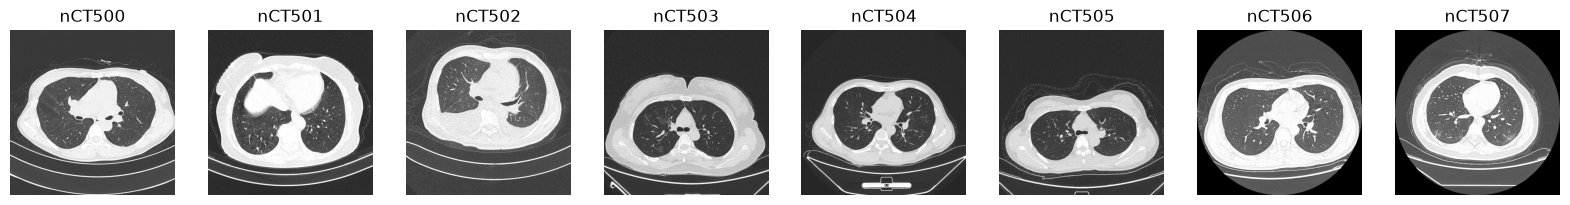

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in zip(range(500, 508), axes):
    img = Image.open(data_dir / "nCT" / f"nCT{i}.jpg")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"nCT{i}")
    ax.axis("off")
plt.show()

**Findings**

- File names consist of the class label and a running number, for example `nCT1.jpg`.
- There is no patient or scan identifier.

A patient-level split is therefore not possible with this dataset. This is a limitation, because slices from the same patient can end up in both the training and the test set.

## 3. Example slices

What do the images look like in each class?

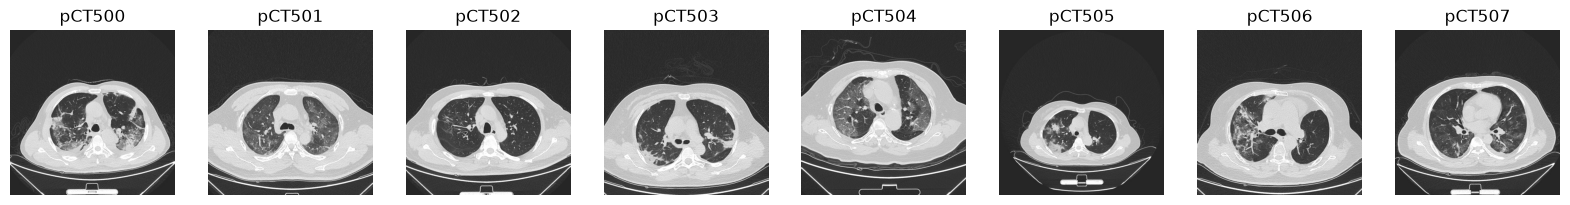

In [23]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in zip(range(500, 508), axes):
    img = Image.open(data_dir / "pCT" / f"pCT{i}.jpg")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"pCT{i}")
    ax.axis("off")
plt.show()

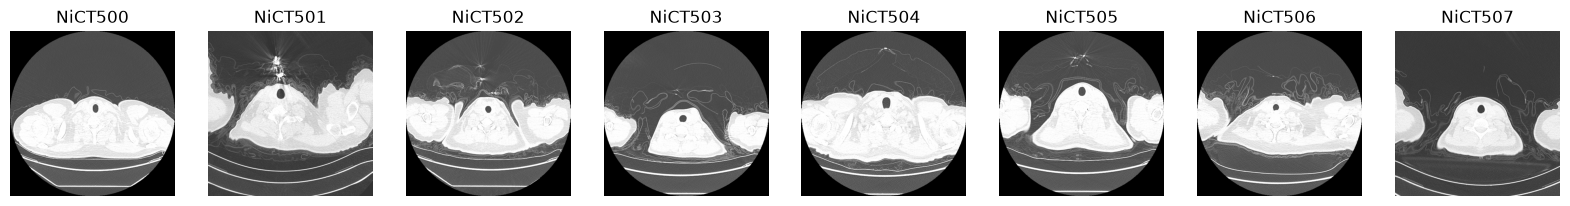

In [24]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in zip(range(500, 508), axes):
    img = Image.open(data_dir / "NiCT" / f"NiCT{i}.jpg")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"NiCT{i}")
    ax.axis("off")
plt.show()

In [25]:
print(img.size, img.mode)

(512, 512) RGB


**Findings**

Based on eight images per class (numbers 500 to 507):

- `nCT`: lungs are clearly visible and evenly dark.
- `pCT`: lungs show hazy, lighter patches.
- `NiCT`: slices at the level of the shoulders and neck, with little or no lung tissue.
- The image I checked is 512 x 512 pixels in RGB mode, although the scans look greyscale.
- Neighbouring file numbers often look very similar, for example `NiCT500` to `NiCT506`. Consecutive files probably come from the same scan, so a random split can put near-identical slices in both train and test.
- There are two image types: slices that fill the whole square, and slices with a circular field of view and black corners.

## 4. Black corners per class

The circular images seemed more common in some classes than in others. To measure this, I flag an image when the mean brightness of its top-left 10 x 10 pixels is below 10 (on a scale of 0 to 255).

In [26]:
import numpy as np

def has_black_corners(path):
    img = np.array(Image.open(path).convert("L"))
    corner = img[:10, :10]
    return corner.mean() < 10

print(has_black_corners(data_dir / "nCT" / "nCT506.jpg"))
print(has_black_corners(data_dir / "nCT" / "nCT500.jpg"))

True
False


In [27]:
for class_dir in data_dir.iterdir():
    files = list(class_dir.glob("*"))
    count = 0
    for f in files:
        if has_black_corners(f):  # does this image have black corners?
            count += 1
    percentage = count / len(files) * 100  # count as a percentage of all files in this class
    print(class_dir.name, count, f"{percentage:.1f}%")

nCT 1849 18.5%
NiCT 833 14.6%
pCT 13 0.3%


**Findings**

- `nCT`: 1,849 images with black corners (18.5%)
- `NiCT`: 833 images (14.6%)
- `pCT`: 13 images (0.3%)

Of the 2,695 images with black corners, only 13 are COVID-positive (0.5%). The positive images were apparently not collected in the same way as the others. A model could use this visual difference as a shortcut instead of looking at the lungs.

Limitation: the check is a simple heuristic. It looks at one corner with a fixed threshold and was verified on two images only.

## Summary and next steps

1. The classes are imbalanced, so I will report per-class metrics next to accuracy.
2. A patient-level split is not possible, so test scores on this dataset are likely optimistic.
3. Image type correlates with class, so I will use Grad-CAM to check what the model looks at.
4. Next: split the data into train, validation and test sets with a fixed seed.